# 10. Local first LLMs

![](https://realpython.com/cdn-cgi/image/width=960,format=auto/https://files.realpython.com/media/How-to-Integrate-Local-LLMs-With-Ollama-and-Python_Watermarked.835ee5f2672d.jpg)

> sauce - https://realpython.com/ollama-python/

## Objetivos

- Instalar LLMs locales
- Explorar las capacidades de LLMs locales
    - Integrarlos con un editor de código para asistencia
- Fundamentos de RAG e implementación con modelos locales

## ollama

![](https://ollama.com/public/ollama.png)

Ollama es una app chiquita que permite obtener y correr LLMs de forma sencilla. Podemos visitar la [documentación](https://github.com/ollama/ollama/blob/main/README.md#quickstart) para saber más características. Hay una lista de modelos disponibles y filtros para identificar sus capacidades.

### Modelos de Embeddings

![](https://ollama.com/public/blog/what-are-embeddings.svg)

Estos modelos estan especialmente diseñados para generar vectores de embeddings (o seá arreglos de números que capturan características semánticas y de otros tipos de la entrada). Estos modelos son fundamentales para crear aplicaciones como *RAGs*.

> source: https://ollama.com/blog/embedding-models

### Modelos con soporte para *tools*

![](https://wallpapercave.com/wp/wp2195747.jpg)

Llamar *tools* le da la posibilidad a los LLMs de realizar tareas complejas o interactuar con entornos fuera del contexto local del LLM:

Ejemplos pueden ser los siguientes:

- Uso de funciones pre-exitentes o APIs
- Navegación en la web
- Utilizar un interprete de código

> source: https://ollama.com/blog/tool-support

### Comandos útiles

In [ ]:
!ollama serve &

In [2]:
!ollama --help

]11;?\Large language model runner

Usage:
  ollama [flags]
  ollama [command]

Available Commands:
  serve       Start Ollama
  create      Create a model
  show        Show information for a model
  run         Run a model
  stop        Stop a running model
  pull        Pull a model from a registry
  push        Push a model to a registry
  signin      Sign in to ollama.com
  signout     Sign out from ollama.com
  list        List models
  ps          List running models
  cp          Copy a model
  rm          Remove a model
  launch      Launch the Ollama menu or an integration
  help        Help about any command

Flags:
  -h, --help         help for ollama
      --nowordwrap   Don't wrap words to the next line automatically
      --verbose      Show timings for response
  -v, --version      Show version information

Use "ollama [command] --help" for more information about a command.


In [3]:
!ollama list

]11;?\NAME                  ID              SIZE      MODIFIED     
gemma4:31b-cloud      c382fbfbc73b    -         2 weeks ago     
qwen2.5-coder:0.5b    4ff64a7f502a    397 MB    5 weeks ago     
qwen3.5:4b            2a654d98e6fb    3.4 GB    5 weeks ago     
qwen3.5:0.8b          f3817196d142    1.0 GB    5 weeks ago     
gemma4:e2b            7fbdbf8f5e45    7.2 GB    6 weeks ago     
gemma3:270m           e7d36fb2c3b3    291 MB    2 months ago    
qwen2.5-coder:3b      f72c60cabf62    1.9 GB    5 months ago    
mistral:latest        6577803aa9a0    4.4 GB    6 months ago    


In [ ]:
!ollama pull <modelo>

### Modelos a utiliza:

- `qwen3-embedding:0.6b`   
- `phi4-mini:latest`
- `gemma3:270m`
- `qwen2.5-coder:0.5b` 

### Probando en terminal

- Usando la CLI

```
$ ollama run <model>
```

- Usando la API

```bash
curl http://localhost:11434/api/chat -d '{
  "model": "gemma3:270m",
  "messages": [
    { "role": "user", "content": "why is the sky blue?" }
  ]
}'
```

- Paquete para `python`

In [ ]:
!pip install ollama

In [17]:
from ollama import chat
from ollama import ChatResponse

response: ChatResponse = chat(model='gemma3:270m', messages=[
  {
    'role': 'user',
    'content': 'Why is the sky blue?',
  },
])

In [18]:
print(response['message']['content'])

The sky is blue because of a phenomenon called **Rayleigh Scattering**. 

Here's a breakdown of the process:

*   **Light Waves:** When light (a form of electromagnetic radiation) encounters a medium (like air, water, or even dust), it absorbs some of the energy.
*   **Interference:** The light then passes through a curtain of air molecules.
*   **Scattering:**  The molecules in the air scatter the light.
*   **Rayleigh Scattering:**  This scattering is what gives the sky its blue color. The scattered light is less energetic than the incident light.
*   **Blue Light:** The blue light has a shorter wavelength than the red light. This means it travels through the air in a much shorter path.

Therefore, the blue color of the sky is due to the high concentration of blue light in the atmosphere.


In [21]:
stream = chat(
    model="gemma3:270m",
    messages=[
  {
    'role': 'user',
    'content': 'What are key elements of quantum computing?',
  },
], stream=True
)

for chunk in stream:
    print(chunk['message']['content'], end='', flush=True)

Quantum computing is a revolutionary approach to computation that leverages the principles of quantum mechanics to solve problems that are intractable for classical computers. Here are the key elements:

*   **Qubits:** Quantum computers leverage the principles of quantum mechanics, specifically the principles of superposition and entanglement. Instead of being bound to a definite state (like a classical bit), qubits can exist in a state of both possibilities simultaneously. This allows for exponentially more computational possibilities than classical bits.

*   **Quantum Algorithms:** Quantum algorithms are designed to solve specific types of problems that are well-suited for quantum computers. These algorithms often involve quantum interference, where multiple qubits interact with each other to explore a solution space.

*   **Quantum Interference:** Quantum interference is a mechanism where qubits can interact with each other in a way that allows for information to be propagated acr

### Integrando llms a nuestro flujo de trabajo local

Vamos a integrar los modelos que obtenemos con `ollama` con VsCode via el plug-in llamado [Continue](https://docs.continue.dev/). Alternativamente se puede realizar la integración con multiples editores como [zed](https://zed.dev/).

#### Demo en vivo (esperemos que salga bien)

- https://docs.continue.dev/guides/ollama-guide
- https://docs.continue.dev/customize/deep-dives/autocomplete

### Configuraciones

```json
# ~/.continue/config.json
models:
  - name: Autodetect
    provider: ollama
    model: AUTODETECT
    roles:
      - chat
      - edit
      - apply
      - rerank
      - autocomplete
```

## Question answering (*Q&A*) y la técnica de Retrieval-augmented generation (*RAG*)

Una tarea que han resuelto los LLMs es la generación de respuestas a preguntas del usuario. Sistemas especializados en *Q&A* de hecho han mostrado ser tan buenos o mejores que personas antes de los LLMs. Por ejemplo, [Watson](https://www.youtube.com/watch?v=P18EdAKuC1U) que ganó el juego Jeopardy en 2011 superando humanos en preguntas como:

> Soy la comida por la que le hacen burla a los chilangos fuera de la CDMX^[1]

[1]: Guajolota

Los sistemas de *Q&A* estan diseñados para completar información de acuerdo a las necesidades de las personas. Ya que mucha información está disponible en forma de texto (como en internet, libros o nuestros emails), estos sistemas están intimamente ligados a los motores de búsqueda. En realidad, esta distinción es cada vez más difusa ya que los motores de búsqueda actuales incorporan LLMs para proponer respuestas.

<center><img src="https://static.boredpanda.com/blog/wp-content/uploads/2024/05/google-ai-overviews-2-66581fd5866f6__700.jpg" width=700></center>

En general los sistemas de *Q&A* se han enfocado en un subtipo de preguntas: **factoides**. Este tipo de preguntas pueden ser respondidas con simples hecho expresados en respuestas cortas o medianas. Por ejemplo:

- ¿Dónde está el Museo de Antropología e Historia de la CDMX?
- ¿Cómo poner el `@` en un teclado en inglés?
- ¿Cómo instalar archlinux sin morir en el intento?^[2]

[2]: Visita la wiki: https://wiki.archlinux.org/

### ❓ Con los temas vistos ¿Cómo resolverían esta tarea?

Una opción es hacer un *fine-tunning* a un modelo pre-entrenado con un *dataset* de question-answering y despues crear prompts con la pregunta y la respuesta en blanco:

> Q: ¿Dónde se encuentra la biblioteca del IIMAS? R: ____

### Problemas de LLMs tirando factos

Los LLMs tienen varias deficiencias a la hora de responder a las preguntas que les hacemos

- **Alucinaciones:** Los modelos tienden a alucinar, esto es que crean respuestas que parecen convincentes y bien formadas pero que no son reales en absoluto. Es dificil saber cuando un modelo está alucinando.
- **Carencia de datos privados:** Los modelos han sido entrenados con grandes cantidades de datos pero no todos los datos posibles. Si queremos que respondan cosas acerca de nuestros correos o registros dentales probablemente no obtendremos respuestas satisfactorias.
- **Datos estáticos:** Los modelos tienen problemas en responder preguntas acerca de eventos cuya información esta cambiando rápidamente. Los LLMs se entrenan con datos hasta alguna fecha.

![](https://i.pinimg.com/originals/82/c1/22/82c122be87204cf8baa442aa27e68a84.gif)

### Acerca de los *RAGs*

Por las razones antes enumeradas, una estrategía para que los LLMs realicen *Q&A* efectivamente es la de *retrieval-augmented generation (RAG)*. *RAG* utiliza técnicas de *Information Retrieval (IR)* para obtener documentos que serán reelevantes para responder a la pregunta del usuario. Despues se utiliza un LLM para generar una respuesta con base en los documentos obtenidos.

Basar las respuestas en los documentos obtenidos resuelve varios de los problemas mencionados anteriormente. En primer lugar, ayuda a que la respuesta esté basada en hecho obtenidos de documentos previamente curados. Además, el sistema puede otorgar al usuario el contexto o documentos que tomó en cuenta para generar la respuesta (un ejemplo: [perplexity AI](https://www.perplexity.ai/search/las-bicicletas-de-pinon-fijo-s-Qr0l4YnETi.Q_d4yrxVyVA)). Esta característica brinda confianza y mayor explicabilidad. Por último, esta técnica permite agregar al sistema información personal o confidencial como registros médicos, legales o notas (aunque mucho ojo con dar sus datos a grandes empresas).

### Arquitectura de un *RAG*

La idea principal es que dada una **pregunta** del usuario y tomando en cuenta un conjunto de **documentos reelevantes** previamente **obtenidos** se **generar** una respuesta. Podemos entonces dividirlo en dos fases:

1. *Retrieval:* Obtenemos los documentos reelevantes de alguna colección
2. *Generation:* Se genera una respuesta con base en estos documentos reelvantes

<center><img src="https://nextcloud.tepezil.net/apps/files_sharing/publicpreview/qsnw9Q8q4TWLQ88?file=/&fileId=74486&x=2560&y=1440&a=true&etag=4560b4a64d98ac7e1e16b563ce2db91e" width=700></center>
> Tomada de Speech and Language Processing, (Jurafsky et al 2025)

Visto de otro modo, la tarea de *Q&A* puede modelarse como predicción de texto de forma auto-regresiva condicionada a un prompt con características particulares.

```
Q: ¿Quien escribió el libro 'Bovedas de acero'? A:
```

$$
p(x_1,...,x_n) = \displaystyle\prod_{i=1}^{n} p(\texttt{[Q:]};q;\texttt{[A:]};x_{<i})
$$

Podemos hacer esto gracias a que los LLMs codifican una enorme cantidad de información en los parámetros gracias al acceso a muchísimos datos de entrenamiento. Sin embargo, si bien esté prompt servirá para responder preguntas *factoides*, aún tendriamos los problemas de alucinaciones, falta de evidencia en la respuesta y limitaciones con datos no disponibles de forma pública.

Los *RAGs* lidian con este problema condicionando la respuesta con documentos reelevantes y algún prompts como: "Con base en los siguientes documentos, contesta la siguiente pregunta:"

Supongase que tenemos una query $q$ y un conjunto de documentos reelevantes a la query $R(q)$ el prompt se vería como se muestra a continuación:

```c
doc 1
doc 2
...
doc n

Con base en los textos anteriores, responde esta pregunta: Q: "¿Quien escribió el libro 'Bovedas de acero'" A:
```

$$
p(x_1,...,x_n) = \displaystyle\prod_{i=1}^{n} p(x_i|R(q);prompt;\texttt{[Q:]};q;\texttt{[A:]};x_{<i})
$$

Se pueden combinar enfoques clásicos como $tfidf$ o $BM25$ con representaciones densas (AKA *embeddings*) de los documentos para la obtención y ordenamiento de los documentos reelevantes. Una parte importante es el *prompt engineering*; decidir como marcar la pregunta o los documentos o si agregar tokens especiales como `[SEP]` puede mejorar o empeorar nuestros resultados.

- [Curso gratuito de Prompt Engineering, DeepLearning.AI](https://www.deeplearning.ai/short-courses/chatgpt-prompt-engineering-for-developers/)

## Creando un RAG con `langchain`

In [1]:
import os
from rich import print as rprint

# Necesario que langchain vea esto
os.environ["OLLAMA_HOST"] = "127.0.0.1"
os.environ["OLLAMA_PORT"] = "11434"

In [3]:
rprint(os.environ["OLLAMA_HOST"])
rprint(os.environ["OLLAMA_PORT"])

127.0.0.1

11434

### Dependencias

```
"langchain-text-splitters>=0.3.8",
"langchain-community>=0.3.21",
"langgraph>=0.4.3",
"langchain-ollama>=0.3.2",
"langchain-chroma>=0.2.2",
```

### Cargando un modelo

In [84]:
from langchain_ollama.chat_models import ChatOllama

MODEL = "qwen3.5:0.8b"

llm = ChatOllama(model=MODEL, reasoning=False)

### Cargando embeddings

In [40]:
from langchain_ollama.embeddings import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

In [41]:
import bs4
from rich import print as rprint
from rich.rule import Rule

### Creación de un motor de búsquedas semánticas

LangChain utiliza abtracciones para integrar la carga y recuperación de información en bases de datos vectoriales, y otras fuentes, en un flujo con LLMs. Estas abstracciones son importantes para aplicaciones que requieren extraer datos y hacer "razonamiento" sobre los mismos como parte de la inferencia (como es el caso del RAG). Estas abstracciones son:

#### Documentos y cargadores

Los documentos representan unidades de texto con metadata que puede carpturar información sobre donde viene el documento, su relación con otros documentos y más.

In [4]:
from langchain_core.documents import Document

documents: list[Document] = [
    Document(
        page_content="Simply put, bikepacking is a mix of all-terrain cycling and backpacking.",
        metadata={"source": "bikepacking-doc"},
    ),
    Document(
        page_content="Bikepacking involves carrying the essential gear—and not much more—on an off-road-capable bike for an overnight or multi-day ride",
        metadata={"source": "bikepacking-doc"},
    ),
]

Sin embargo, es más común utilizar [*doc loaders*](https://python.langchain.com/docs/concepts/document_loaders/) para obtener [integraciones](https://python.langchain.com/docs/integrations/document_loaders/) varias con fuentes de datos.

In [5]:
from langchain_community.document_loaders import WebBaseLoader

# Cargador basado en extracción de datos de la web
loader = WebBaseLoader(
    web_paths=(
        "https://lilianweng.github.io/posts/2023-06-23-agent/",
        "https://www.davidsbatista.net/blog/2017/11/13/Conditional_Random_Fields/",
        "https://www.davidsbatista.net/blog/2017/11/12/Maximum_Entropy_Markov_Model/"
        ),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header", "post")
        )
    ),
)
docs = loader.load()

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [6]:
rprint(f"Total documents {len(docs)}")
for i, doc in enumerate(docs, start=1):
    rprint(Rule(f"Doc {i}"))
    rprint(doc.page_content[:300])
    rprint(doc.metadata)

Total documents 3

────────────────────────────────────────────────────── Doc 1 ──────────────────────────────────────────────────────

LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts
demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as i

{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}

────────────────────────────────────────────────────── Doc 2 ──────────────────────────────────────────────────────

Conditional Random Fields for Sequence Prediction


        13 November 2017
      



This is the third and (maybe) the last part of a series of posts about sequential supervised learning applied to 
NLP. In this post I will talk about Conditional Random Fields (CRF), explain what was the main mot

{'source': 'https://www.davidsbatista.net/blog/2017/11/13/Conditional_Random_Fields/'}

────────────────────────────────────────────────────── Doc 3 ──────────────────────────────────────────────────────

Maximum Entropy Markov Models and Logistic Regression


        12 November 2017
      



This is the second part of a series of posts about sequential supervised learning applied to NLP. It can be seen as
a follow-up to the previous post, where I tried to explain the relationship between HMM and

{'source': 'https://www.davidsbatista.net/blog/2017/11/12/Maximum_Entropy_Markov_Model/'}

#### Separadores de texto (*text splitters*)

Típicamente en las aplicaciones de recuperación de información o *question answering* una página de un documento puede ser demasiado grande para una representación. Lo que buscamos es obtener partes del documento para contestar preguntas basadas en la *query* de entrada y separar los documentos va a prevenir que porciones reelevantes del texto no sean opacadas por texto alrededor.

Definiremos la cantidad de caracteres que tendrá cada *chunk* y los caracteres de *overlap*, que ayuda a mitigar que perdamos información reelevante al separar el documento. `RecursiveCharacterTextSplitter` separará recursivamente utilizando el salto de línea hasta obtener *chunks* del tamaño deseado.

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=50, add_start_index=True)
all_splits = text_splitter.split_documents(docs)

In [8]:
rprint(f"Splits {len(all_splits)}")
for i, split in enumerate(all_splits[80:90], start=1):
    rprint(Rule(f"split #{i}"))
    rprint(split)

Splits 94

──────────────────────────────────────────────────── split #1 ─────────────────────────────────────────────────────

Document(
    metadata={
        'source': 'https://www.davidsbatista.net/blog/2017/11/12/Maximum_Entropy_Markov_Model/',
        'start_index': 618
    },
    page_content='Discriminative vs. Generative Models\nIn a previous post I wrote about the Naive Bayes Model and 
how it is connected with the Hidden Markov Model. Both are generative models, in contrast, Logistic Regression is a
discriminative model, this post will start, by explaining this difference.\nIn general, a machine learning 
classifier chooses which output label \\(y\\) to assign to a given input \\(x\\), by selecting from all the 
possible \\(y_{i}\\) the one that maximizes \\(P(y\\mid x)\\).\nThe Naive Bayes classifier estimates \\(p(y \\mid 
x)\\) indirectly, by applying Baye’s theorem, and then computing the class conditional distribution/likelihood 
\\(P(x \\mid y)\\) and the prior \\(P(y)\\).\n\n\\[\\hat{y} = \\underset{y}{\\arg\\max}\\ P(y \\mid x) = 
\\underset{y}{\\arg\\max} \\ P(x \\mid y) \\cdot P(y)\\]'
)

──────────────────────────────────────────────────── split #2 ─────────────────────────────────────────────────────

Document(
    metadata={
        'source': 'https://www.davidsbatista.net/blog/2017/11/12/Maximum_Entropy_Markov_Model/',
        'start_index': 1398
    },
    page_content='This indirection makes Naive Bayes a generative model, a model that is trained to generate the 
data \\(x\\) from the class \\(y\\). The likelihood \\(p(x \\mid y)\\), means that we are given a class \\(y\\) and
will try to predict which features to see in the input \\(x\\).\nIn contrast, a discriminative model directly 
computes \\(p(y \\mid x)\\) by discriminating among the different possible values of the class \\(y\\) instead of 
computing a likelihood. The Logistic Regression classifier is one such type of classifier.\n\n\\[\\hat{y} = 
\\underset{y}{\\arg\\max} \\ P(y \\mid x)\\]\n\n\nLogistic Regression\nLogistic regression is a supervised machine 
learning algorithm used for classification, which has its roots in linear regression.\nWhen used to solve NLP 
tasks, it estimates \\(p( y\\mid x)\\) by extracting features from the input text and combining them linearly i.e.,
multiplying each feature by a weight and then adding them up, and then applying the exponential function to this 
linear combination:'
)

...

Document(
    metadata={
        'source': 'https://www.davidsbatista.net/blog/2017/11/12/Maximum_Entropy_Markov_Model/',
        'start_index': 6732
    },
    page_content='In the Maximum Entropy Markov Models the transition and observation functions (i.e., the HMM 
matrices \\(A\\) and \\(B\\) from the previous post) are replaced by a single function:\n\n\\[P(s_{t} \\mid 
s_{t-1}, o_{t})\\]\n\nthe probability of the current state \\(s_{t}\\) given the previous state \x16\\(s_{t-1}\\) 
and the current observation \x14\\(o\\). The figure below shows this difference in computing the state/label/tag 
transitions.\n\n\n\n  The contrast in state transition estimation between an HMM and a MEMM.  (taken from "Speech 
and Language Processing" Daniel Jurafsky & James H. Martin)'
)

──────────────────────────────────────────────────── split #9 ─────────────────────────────────────────────────────

Document(
    metadata={
        'source': 'https://www.davidsbatista.net/blog/2017/11/12/Maximum_Entropy_Markov_Model/',
        'start_index': 7308
    },
    page_content='In contrast to HMMs, in which the current observation only depends on the current state, the 
current observation in a MEMM may also depend on the previous state. The HMM model includes distinct probability 
estimates for each transition and observation, while the MEMM gives one probability estimate per hidden state, 
which is the probability of the next tag given the previous tag and the observation.\nIn the MEMM instead of the 
transition and observation matrices, there is only one transition probability matrix. This matrix encapsulates all 
combinations of previous states \\(S_{t−1}\\) and current observation \\(O_{t}\\) pairs in the training data to the
current state \\(S_{t}\\).\nLet \\(N\\) be the number of unique states and \\(M\\) the number of unique words, the 
matrix has the shape:\n\n\\[(N \\cdot M) \\cdot N\\]'
)

──────────────────────────────────────────────────── split #10 ────────────────────────────────────────────────────

Document(
    metadata={
        'source': 'https://www.davidsbatista.net/blog/2017/11/12/Maximum_Entropy_Markov_Model/',
        'start_index': 8095
    },
    page_content="\\[(N \\cdot M) \\cdot N\\]\n\nFeatures Functions\nThe MEMM can condition on any useful feature 
of the input observation, in the HMM this wasn’t possible because the HMM is likelihood-based, and hence we would 
have needed to compute the likelihood of each feature of the observation.\nThe use of state-observation transition 
functions, rather than the separate transition and observation functions as in HMMs, allows us to model transitions
in terms of multiple, non-independent features of observations.\nThis is achieved by a multinomial logistic 
regression, to estimate the probability of each local tag given the previous tag (i.e., \\(s'\\)), the observed 
word (i.e. \\(o\\)), and any other features (i.e., \\(f_{i}(x,y')\\)) we want to include:\n\n\\[P(s \\mid s',o) = 
\\frac{1}{Z(o,s')}\\  \\exp\\bigg( \\sum_{i=1}^{N} w_{i} \\cdot f_{i}(o,s') \\bigg)\\]"
)

#### Embeddings

La forma habitual de hacer búsquedas en textos no estructurados es por medio de vectores. Recordemos que las representaciones vectoriales son útiles para hacer búsquedas basandonos en una medida de similitud (ej: *cosine similarity*).

In [9]:
vector_1 = embeddings.embed_query(all_splits[0].page_content)
vector_2 = embeddings.embed_query(all_splits[1].page_content)

assert len(vector_1) == len(vector_2)
rprint(f"Generated vectors of length {len(vector_1)}")
rprint("V1", vector_1[:10])
rprint("V2", vector_2[:10])

Generated vectors of length 1024

V1
[
    0.029261125,
    -0.0007124706,
    -0.0063637877,
    -0.065147996,
    -0.036847785,
    -0.019607868,
    -0.021246236,
    0.013781183,
    0.007776401,
    -0.004164105
]

V2
[
    -0.051416103,
    0.01434917,
    -0.008537515,
    -0.08987881,
    -0.042777613,
    -0.009654615,
    -0.018999627,
    -0.002890253,
    -0.04732659,
    0.01888331
]

#### Creando la base de datos de embeggings

Los objetos `VectorStore` de langchain exponen métodos para agregar texto o `Documents` al almacenamiento y realizar *queries* con base en multiples medidas de similitud. Se inicializan con modelos de embeddings (en nuestro caso [Nomic Embed Text](https://ollama.com/library/nomic-embed-text)) que determinará como es que el texto será transformado a una representación vectorial.

In [10]:
from langchain_chroma import Chroma

vector_store = Chroma(
    # Nombramos nuestra colección
    collection_name="my_collection",
    # embeddings lo definimos más arriba
    embedding_function=embeddings,
    # Where to save data locally
    persist_directory="./my_chroma_langchain_db",
)

Una vez creada la base de datos vectorial podemos indexar los documentos y dada una *query* de entrada obtener documentos reelevantes.

In [11]:
%%time
ids = vector_store.add_documents(documents=all_splits)

CPU times: user 76.5 ms, sys: 23 ms, total: 99.5 ms
Wall time: 53.5 s


In [12]:
rprint(ids[:10])

[
    '2c845e2d-38ea-4e73-b080-a606471e6c4e',
    'cff00c0b-3d16-46e5-9d01-8ef7da2e76e4',
    '5e4e96c6-6229-4616-8993-46541766d03c',
    '7aa63fb1-457d-4efb-bae6-bce2f69441e5',
    '755fd6eb-32c9-4acd-ac03-179fc11a0982',
    'e29f4938-0ea4-4927-9551-253052e699cb',
    '3e056c86-70d6-4655-b19c-c56ab99aa43a',
    'dcbd399c-0ffb-4a03-90b1-8e8786c14466',
    '68d5f229-1484-48e6-a260-90d5c35e6e23',
    'b6ca96c4-ada4-4885-8b92-b8c866a81d2b'
]

In [13]:
results = await vector_store.asimilarity_search("Conditional Random Fields", k=3)

rprint(results)

[
    Document(
        id='1320e5ed-fdbb-4a99-925b-fb008d51bc39',
        metadata={
            'start_index': 12823,
            'source': 'https://www.davidsbatista.net/blog/2017/11/13/Conditional_Random_Fields/'
        },
        page_content='References\n\n\n“Conditional Random Fields: Probabilistic Models for Segmenting and Labeling 
Sequence Data”\n\n\n“Log-linear models and Conditional Random Fields”. Notes for a tutorial at CIKM’08 by Charles 
Elkan. October 20, 2008”\n\n\nVideo: tutorial at CIKM’08 by Charles Elkan\n\n\n“Conditional Random Fields: An 
Introduction”. Hanna M. Wallach, February 24, 2004. University of Pennsylvania CIS Technical Report 
MS-CIS-04-21\n\n\n“Statistical NLP for the Web Log Linear Models, MEMM, Conditional Random Fields” class by Sameer 
Maskey\n\n\n“Log-Linear Models, MEMMs, and CRFs”. Michael Collins\n\n\n“An Introduction to Conditional Random 
Fields” Sutton, Charles; McCallum, Andrew (2010)\n\n\nAcknowledgments\nThe writing of this post is also the outcome
of many discussions and white board sessions I had together with Tobias Sterbak and Sebastian Mika.\nRelated 
posts\n\n\nHidden Markov Model and Naive Bayes relationship\n\n\nMaximum Entropy Markov Models and Logistic 
Regression'
    ),
    Document(
        id='d29736c1-d6e7-4c92-ac8b-fe713cc2bef8',
        metadata={
            'start_index': 2,
            'source': 'https://www.davidsbatista.net/blog/2017/11/13/Conditional_Random_Fields/'
        },
        page_content='Conditional Random Fields for Sequence Prediction\n\n\n        13 November 2017\n      
\n\n\n\nThis is the third and (maybe) the last part of a series of posts about sequential supervised learning 
applied to NLP. In this post I will talk about Conditional Random Fields (CRF), explain what was the main 
motivation behind the proposal of this model, and make a final comparison between Hidden Markov Models (HMM), 
Maximum Entropy Markov Models (MEMM) and CRF for sequence prediction.\nYou can find the first and second posts 
here:\n\n\nHidden Markov Model and Naive Bayes relationship\n\n\nMaximum Entropy Markov Models and Logistic 
Regression'
    ),
    Document(
        id='cd342289-ad77-4c05-b209-6cac11b735a3',
        metadata={
            'start_index': 5030,
            'source': 'https://www.davidsbatista.net/blog/2017/11/13/Conditional_Random_Fields/'
        },
        page_content='where \\(w \\sim v\\) means that \\(w\\) and \\(v\\) are neighbours in G. Thus, a CRF is a 
random field globally conditioned on the observation \\(X\\). This goes already in the direction of what the MEMM 
doesn’t give us, states globally conditioned on the observation.\nThis graph may have an arbitrary structure as 
long as it represents the label sequences being modelled, this is also called general Conditional Random 
Fields.\nHowever, the simplest and most common graph-structured in NLP, which is the one used to model sequences is
the one in which the nodes corresponding to elements of \\(Y\\) form a simple first-order chain, as illustrated in 
the figure below:\n\n\nChain-strucutred CRFs globally conditioned on X.\n   (taken from Hanna Wallach 2004)\n\nThis
is also called linear-chain conditional random fields, which is the type of CRF on which the rest of this post will
focus.\nLinear-chain CRFs\nLet \\(\\bar{x}\\) is a sequence of words and \\(\\bar{y}\\) a corresponding sequence of
\\(n\\) tags:'
    )
]

In [14]:
embedding = embeddings.embed_query("What are the difference beetween HMM and MEMM?")

results = vector_store.similarity_search_by_vector(embedding)
rprint(f"Results={len(results)}")
for i, result in enumerate(results):
    rprint(Rule(f"Result #{i}"))
    rprint(result.page_content)

Results=4

──────────────────────────────────────────────────── Result #0 ────────────────────────────────────────────────────

There is an exponential model associated with each (state, word) pair to calculate the conditional probability of 
the next state.


The exponential model allows the MEMMs to support long-distance interactions over the whole observation sequence 
together with the previous state, instead of two different probability distributions.


MEMM can be also augmented to include features involving additional past states, instead of just the previous one.


It also uses the Viterbi algorithm (slightly adapted) to perform decoding.


It suffers from the label bias problem, which I will detail in the next post about Conditional Random Fields.


Software Packages


https://github.com/willxie/hmm-vs-memm: a project for a class by William Xie which implements and compares HMM vs. 
MEMM on the task of part-of-speech tagging.


https://github.com/yh1008/MEMM: an implementation by Emily Hua
for the task of noun-phrase chunking.

──────────────────────────────────────────────────── Result #1 ────────────────────────────────────────────────────

In contrast to HMMs, in which the current observation only depends on the current state, the current observation in
a MEMM may also depend on the previous state. The HMM model includes distinct probability estimates for each 
transition and observation, while the MEMM gives one probability estimate per hidden state, which is the 
probability of the next tag given the previous tag and the observation.
In the MEMM instead of the transition and observation matrices, there is only one transition probability matrix. 
This matrix encapsulates all combinations of previous states \(S_{t−1}\) and current observation \(O_{t}\) pairs in
the training data to the current state \(S_{t}\).
Let \(N\) be the number of unique states and \(M\) the number of unique words, the matrix has the shape:

[(N \cdot M) \cdot N\]

──────────────────────────────────────────────────── Result #2 ────────────────────────────────────────────────────

Training and Decoding
Taken from the original paper: “In what follows, we will split \(P(s \mid s', O)\) into \(\mid S \mid\) separately 
trained transition functions \(P_{s'} ( S \mid o) = P(s \mid s', O)\). Each of these functions is given by an 
exponential model”
THE MEMM trains one logistic regression per state transition, normalised locally. The original MEMM paper, 
published in 2000, used a generalised iterative scaling (GIS) algorithm to fit the multinomial logistic regression,
that is finding the perfect weights according to the training data. That algorithm has been largely surpassed by 
gradient-based methods such as L-BFGS.
For the decoding, the same algorithm as in the HMM is used, the Viterbi, although just slightly adapted to 
accommodate the new method of estimating state transitions.



MEMM Important Observations


The main advantage over the HMM is the use of feature vectors, making the transition probability sensitive to any 
word in the input sequence.

──────────────────────────────────────────────────── Result #3 ────────────────────────────────────────────────────

In the Maximum Entropy Markov Models the transition and observation functions (i.e., the HMM matrices \(A\) and 
\(B\) from the previous post) are replaced by a single function:

[P(s_{t} \mid s_{t-1}, o_{t})\]

the probability of the current state \(s_{t}\) given the previous state \(s_{t-1}\) and the current observation 
\(o\). The figure below shows this difference in computing the state/label/tag transitions.



  The contrast in state transition estimation between an HMM and a MEMM.  (taken from "Speech and Language 
Processing" Daniel Jurafsky & James H. Martin)

#### Generación

La lógica de la app consistirá en los siguientes pasos:

1. Tomar la pregunta del usuario
2. Obtener documentos reelevantes a la pregunta en cuestión
    - La obtención de los documentos estará superditada por el *retriever* que definamos
3. Pasar los documentos obtenidos y la pregunta inicial al modelo
4. Generar una respuesta
    - Para la generación usaremos el modelo obtenido de `ollama`

#### Creando el prompt

In [97]:
from langchain_core.prompts import ChatPromptTemplate

PROMPT_TEMPLATE = """
You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the
question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the
answer concise
Question: {question}
Context: {context}
Answer:
"""

prompt = ChatPromptTemplate.from_template(PROMPT_TEMPLATE)

In [98]:
example_messages = prompt.invoke(
    {"context": "[blue]<My retrieved and absolutely relevant documents>[/]", "question": "[green]<The question in question>[/]"}
).to_messages()

rprint(example_messages[0].content)

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the
question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the
answer concise
Question: <The question in question>
Context: <My retrieved and absolutely relevant documents>
Answer:

In [87]:
# 1. Pregunta del user
question = input(f"panzaGPT [{MODEL}]>> ")

# 2. Obtener documentos reelevantes
retrieved_docs = vector_store.similarity_search(question)
docs_content = "\n\n".join(doc.page_content for doc in retrieved_docs)

# 3. Pasarlos a junto con la pregunta al modelo
prompt_result = prompt.invoke({"question": question, "context": docs_content})

# 4. Generar una respuesta
answer = llm.invoke(prompt_result)

In [88]:
rprint(answer)

AIMessage(
    content='{\n    "thoughts": {\n        "text": "The CRF paper, as noted in the context, introduced Conditional 
Random Fields which differed from previous models like MEMM by using a single global exponential model to determine
joint probabilities across all states rather than per-state models for individual state transitions. This implies 
that CRFs compete for the same weights associated with different feature states. While the core definition is 
simple, it is important to distinguish CRFs from CRFs. The text mentions that CRFs were proposed roughly a year 
after the Maximum Entropy Markov Model, suggesting they are a distinct, innovative variant. The context highlights 
that MEMMs use exponential models per-state while CRFs use a single exponential model for the joint probability of 
the entire sequence. Therefore, the key distinction is that CRFs compute a joint probability matrix for the entire 
sequence of labels versus per-state models for individual states."\n    },\n    "command": {\n        "name": 
"answer",\n        "args": {\n            "arg name": "CRFs compute a single exponential model to determine the 
joint probability of the entire sequence of labels, given the observation sequence, which differs from the MEMM 
approach where per-state exponential models are used."\n        }\n    }\n}',
    additional_kwargs={},
    response_metadata={
        'model': 'qwen3.5:0.8b',
        'created_at': '2026-05-19T01:04:22.824973005Z',
        'done': True,
        'done_reason': 'stop',
        'total_duration': 18000728616,
        'load_duration': 167322678,
        'prompt_eval_count': 819,
        'prompt_eval_duration': 1331576993,
        'eval_count': 258,
        'eval_duration': 16311114972,
        'logprobs': None,
        'model_name': 'qwen3.5:0.8b',
        'model_provider': 'ollama'
    },
    id='lc_run--019e3dc2-ead7-7ac0-ad44-2c2d3e4921c7-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 819, 'output_tokens': 258, 'total_tokens': 1077}
)

In [89]:
rprint(answer.content)

{
    "thoughts": {
        "text": "The CRF paper, as noted in the context, introduced Conditional Random Fields which differed from 
previous models like MEMM by using a single global exponential model to determine joint probabilities across all 
states rather than per-state models for individual state transitions. This implies that CRFs compete for the same 
weights associated with different feature states. While the core definition is simple, it is important to 
distinguish CRFs from CRFs. The text mentions that CRFs were proposed roughly a year after the Maximum Entropy 
Markov Model, suggesting they are a distinct, innovative variant. The context highlights that MEMMs use exponential
models per-state while CRFs use a single exponential model for the joint probability of the entire sequence. 
Therefore, the key distinction is that CRFs compute a joint probability matrix for the entire sequence of labels 
versus per-state models for individual states."
    },
    "command": {
        "name": "answer",
        "args": {
            "arg name": "CRFs compute a single exponential model to determine the joint probability of the entire 
sequence of labels, given the observation sequence, which differs from the MEMM approach where per-state 
exponential models are used."
        }
    }
}

In [90]:
ans_struct = eval(answer.content)
rprint(ans_struct["thoughts"]["text"])

The CRF paper, as noted in the context, introduced Conditional Random Fields which differed from previous models 
like MEMM by using a single global exponential model to determine joint probabilities across all states rather than
per-state models for individual state transitions. This implies that CRFs compete for the same weights associated 
with different feature states. While the core definition is simple, it is important to distinguish CRFs from CRFs. 
The text mentions that CRFs were proposed roughly a year after the Maximum Entropy Markov Model, suggesting they 
are a distinct, innovative variant. The context highlights that MEMMs use exponential models per-state while CRFs 
use a single exponential model for the joint probability of the entire sequence. Therefore, the key distinction is 
that CRFs compute a joint probability matrix for the entire sequence of labels versus per-state models for 
individual states.

### Obtenedores (*Retrievers*) y LangGraph

#### Retrievers

Los objetos que heredan de los [*Runnables*](https://python.langchain.com/api_reference/core/index.html#langchain-core-runnables) implementan un conjunto de métodos sincronos y asíncronos. Uno de estos objetos son los [*Retrievers*](https://python.langchain.com/api_reference/core/index.html#langchain-core-retrievers). Podemos obtener *retrievers* de los *vector_stores* o construir los propios.

#### LangGraph

LangGraph es un orquestador que nos permitirá administrar los pasos de obtención y generación. En general utilizar `langgraph` permite escalar nuestras apps y construir agentes de forma "sencilla". Algunas características interesantes son las siguientes:

- Definir la lógica de la app una vez habilitar soporte para multiples modelos, llamadas async y batches
- Perminte agregar fácilmente características como [persistencia](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpoints), [aprobación human-in-the-loop](https://langchain-ai.github.io/langgraph/concepts/human_in_the_loop/)

Para usar `langgraph` precisamos tres ingredientes:

1. Una forma de modelar los estados
2. Nodos por los que pasará
3. Un flujo de control

In [91]:
from typing import TypedDict

class State(TypedDict):
    """Define the states of the app"""
    question: str
    context: list[Document]
    answer: str

In [99]:
from langgraph.graph import START, StateGraph

# Define app steps
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

In [104]:
# Define control flow
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
# Add a new node
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

In [105]:
response = graph.invoke({"question": "What is a CRF?"})
rprint(eval(response["answer"])["thoughts"]["text"])

The user asks about CRF (Conditional Random Field). Based on the context, I need to identify the core conceptual 
difference between CRF and other models like MEMM, then briefly explain the process for an AI assistant to handle 
such a task.

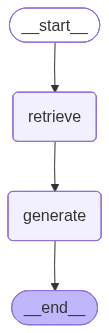

In [96]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Multiples formas de invocar nuestro grafo (gráfica (?))

In [102]:
for step in graph.stream(
    {"question": "What is Task Decomposition?"}, stream_mode="updates"
):
    rprint(f"{step}\n\n----------------\n")

{'retrieve': {'context': [Document(id='83d85979-bde2-48e7-a0c1-2fbb9caf656c', metadata={'start_index': 17734, 
'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='The AI assistant can parse user 
input to several tasks: [{"task": task, "id", task_id, "dep": dependency_task_ids, "args": {"text": text, "image": 
URL, "audio": URL, "video": URL}}]. The "dep" field denotes the id of the previous task which generates a new 
resource that the current task relies on. A special tag "-task_id" refers to the generated text image, audio and 
video in the dependency task with id as task_id. The task MUST be selected from the following options: {{ Available
Task List }}. There is a logical relationship between tasks, please note their order. If the user input can\'t be 
parsed, you need to reply empty JSON. Here are several cases for your reference: {{ Demonstrations }}. The chat 
history is recorded as {{ Chat History }}. From this chat history, you can find the path of the user-mentioned 
resources for your task planning.'), Document(id='e18f5b59-1eec-4d30-9075-e4d40818df50', metadata={'start_index': 
25955, 'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content="Prompt LM with 100 most 
recent observations and to generate 3 most salient high-level questions given a set of observations/statements. 
Then ask LM to answer those questions.\n\n\nPlanning & Reacting: translate the reflections and the environment 
information into actions\n\nPlanning is essentially in order to optimize believability at the moment vs in 
time.\nPrompt template: {Intro of an agent X}. Here is X's plan today in broad strokes: 1)\nRelationships between 
agents and observations of one agent by another are all taken into consideration for planning and 
reacting.\nEnvironment information is present in a tree structure.\n\n\n\n\n\nThe generative agent architecture. 
(Image source: Park et al. 2023)"), Document(id='0c45e736-e11b-43da-af08-65413b997079', metadata={'start_index': 
18591, 'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='(2) Model selection: LLM 
distributes the tasks to expert models, where the request is framed as a multiple-choice question. LLM is presented
with a list of models to choose from. Due to the limited context length, task type based filtration is 
needed.\nInstruction:\n\nGiven the user request and the call command, the AI assistant helps the user to select a 
suitable model from a list of models to process the user request. The AI assistant merely outputs the model id of 
the most appropriate model. The output must be in a strict JSON format: "id": "id", "reason": "your detail reason 
for the choice". We have a list of models for you to choose from {{ Candidate Models }}. Please select one model 
from the list.\n\n(3) Task execution: Expert models execute on the specific tasks and log results.\nInstruction:'),
Document(id='fad39c49-aa44-41e1-93ec-3967801b70bb', metadata={'source': 
'https://lilianweng.github.io/posts/2023-06-23-agent/', 'start_index': 30104}, page_content='You should only 
respond in JSON format as described below\nResponse Format:\n{\n    "thoughts": {\n        "text": "thought",\n    
"reasoning": "reasoning",\n        "plan": "- short bulleted\\n- list that conveys\\n- long-term plan",\n        
"criticism": "constructive self-criticism",\n        "speak": "thoughts summary to say to user"\n    },\n    
"command": {\n        "name": "command name",\n        "args": {\n            "arg name": "value"\n        }\n    
}\n}\nEnsure the response can be parsed by Python json.loads\nGPT-Engineer is another project to create a whole 
repository of code given a task specified in natural language. The GPT-Engineer is instructed to think over a list 
of smaller components to build and ask for user input to clarify questions as needed.\nHere are a sample 
conversation for task clarification sent to OpenAI ChatCompletion endpoint used by GPT-Engine

{'generate': {'answer': 'Based on the provided context, here is the answer:\n1. **Task Decomposition** refers to 
the process of organizing a user input into a sequence of smaller, manageable tasks, where each task relies on a 
specific "dependency" task_id to generate a resource.\n2. To select a model for complex reasoning, the AI must 
analyze "relationships between agents and observations" and filter candidates based on "task type based 
filtration."\n3. The final output must be a strict JSON object containing the model\'s reasoning for selection and 
a short bulleted list for the long-term plan.'}}

----------------

In [103]:
for message, metadata in graph.stream(
    {"question": "What is Task Decomposition?"}, stream_mode="messages"
):
    print(message.content, end="")

{
  "thoughts": {
    "text": "The prompt describes GPT-Engineer as an agent tasked with breaking down a natural language task into smaller components and requesting clarification on user inputs.\nThe context also lists tasks related to dependency tasks, resource planning, and logical relationships.\nThe user request asks me to summarize the key concepts of 'Task Decomposition' based on the context, but there is no specific question or question text to answer.",
    "reasoning": "The retrieved context discusses two different AI assistant architectures (Prompt LM and GPT-Engineer) and mentions general concepts like dependency tasks, resource planning, and logical relationships. However, the specific context for Task Decomposition is not provided, nor does the current context ask a question about it. Therefore, I do not have enough information to answer the specific question requested.",
    "speak": "I do not know the answer to your question. The context provided discusses Task Decompos

## Dando posibilidades conversacionales al RAG

Hoy día es muy popular interactuar con estos sistemas de Q&A a traves de una interfaz de chat conversacional. Esto es permitir que el usuario tenga una conversación de ida y vuelta con nuestro sistema. Esto implica que el sistema debe tener "memoria" para acceder a las preguntas y respuestas pasadas y cierta lógica para incorporar el historial para generar nuevas respuestas.

Una forma modelar la interface conversacional es a traves de [mensajes](https://python.langchain.com/docs/concepts/messages/) con ciertos roles (user, IA, system), contenido y metadata. En particular los estados de nuestro RAG serán representado como secuencias de mensajes con las siguientes particularidades:

1. Entrada del usuario modelada como `HumanMessage`
2. La query que haremos al *vector store* como `AIMessage`
3. Los documentos reelevantes como `ToolMessage`
4. La respuesta final como `AIMessage`

Este modelo de estadod viene integrado en LangGraph

In [112]:
from langgraph.graph import MessagesState, StateGraph

graph_msg_builder = StateGraph(MessagesState)

### Tool calling

Permitir que se realizen llamadas a *tools* en la etapa de *retrieval* posibilitará que el modelo genera la query.

#### ❓ ¿Porqué sería reelevante hacer esto?

En una conversación puede que la query del usuario deba contextualizarse basandonos en el historial. Por ejemplo:

```
User: ¿Qué es el mole?

IA: El model es un platillo mexicano, a base de chocolate, pimienta, pan (bolillo), tortilla tostada, chiles, tomate, cebolla, clavo (especie), comino, nuez, almendra (no en todos los tipos de mole), laurel.

User: ¿Cuál es la forma mas sencilla de prepararlo?
```

En este caso, el modelo debería generar una query del esitlo: "formas sencillas de preparar mole". Habilitar llamadas a *tools* permite esta generación.

In [106]:
# Convirtiendo nuestro retrieve en una tool
from langchain_core.tools import tool


@tool(response_format="content_and_artifact")
def retrieve_tool(query: str):
    """Retrieve information related to a user query"""
    retrieved_docs = vector_store.similarity_search(query)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\nContent: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs

Más sobre crear *tools* en la [docu](https://python.langchain.com/docs/how_to/custom_tools/). Acá explican porqué `response_format="content_and_artifact"`

El grafo consistirá en tres nodos:

1. Un nodo que procesa la entrada del usuario y genera una query para el *retriever* o responde directamente
2. Otro nodo para el *retriever tool* que ejecutará la obtención de los documentos reelevantes
3. El último nodo que genera la respuesta final utilizando el contexto del *retriever*

Los elementos del grafo se definen acontinuación

In [107]:
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode

# 1. Generamos un AIMessage que podría incluir la llamada a una tool
def query_or_respond(state: MessagesState):
    """Genera una tool call para retrieval o responde directo
    """
    llm_with_tools = llm.bind_tools([retrieve_tool])
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

In [108]:
# 2. Ejecutamos el paso de *retrieval*
tools = ToolNode([retrieve_tool])

In [109]:
# 3. Generamos la respuesta utilizando el contenido obtenido
def generate(state: MessagesState):
    """Genera una respuesta"""
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        if not message.type == "tool":
            break
        recent_tool_messages.append(message)
    # Obtenemos los mensajes de tools en orden inverso
    tool_messages = recent_tool_messages[::-1]
    # Creando un prompt con los mensajes
    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    system_message = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. If you don't know the answer, say that you "
        "don't know. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"
    )
    convertation = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]
    prompt = [SystemMessage(system_message)] + convertation

    response = llm.invoke(prompt)
    return {"messages": [response]}

#### Construyendo el grafo

Concentraremos los elementos definidos anteriormente en un solo objeto `graph`. Conectaremos los pasos en una secuencia y permitiremos que el primer paso `query_or_respond` realice un *short-circuit* y responda directamente en caso de no necesitar llamas a las *tools*. Esto permire que nuestro RAG brinde una experiencia conversacional más "natural", por ejemplo: respondiendo a saludos del usuario donde, en principio, no se requeriría ir a la base de datos vectorial.

In [113]:
from langgraph.graph import END
from langgraph.prebuilt import ToolNode, tools_condition

graph_msg_builder.add_node(query_or_respond)
graph_msg_builder.add_node(tools)
graph_msg_builder.add_node(generate)

graph_msg_builder.set_entry_point("query_or_respond")
graph_msg_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "tools"}
)

graph_msg_builder.add_edge("tools", "generate")
graph_msg_builder.add_edge("generate", END)

graph_tools = graph_msg_builder.compile()

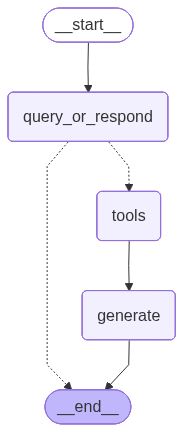

In [114]:
from IPython.display import Image, display

display(Image(graph_tools.get_graph().draw_mermaid_png()))

### Pruebas del RAG

In [115]:
input_message = "Hello"

for step in graph_tools.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello! How can I help you today?


Vemos que no ejecutó el paso de *retriever*

In [119]:
input_message = "What is a CRF model?"

for step in graph_tools.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is a CRF model?
================================== Ai Message ==================================

A **CRF (Conditional Random Field)** is a statistical modeling framework primarily used in natural language processing (NLP) and computer vision to learn probabilistic relationships between words and words (and between words and images) in a sequence of words or pixels.

It is a powerful, general-purpose method for extracting context from unstructured data, making it highly effective in tasks like natural language understanding (NLU) and semantic segmentation.

### Key Characteristics and Logic
Unlike models that simply predict the next word in a sequence based on a fixed rule or a fixed pattern, a CRF model uses **conditional probability**. It defines how the probability of a word occurring at a specific position depends on all preceding words. This allows it to capture context and relationships that st